# Self-supervised photometry: all ten bands

Rubin **u/g/r/i/z/y** and Euclid **VIS/Y/J/H**, fitted on their stored native grids. The head learns from image pixels, with **no MER flux labels**. A frozen v11 foundation supplies local features; a frozen compatible astrometry head supplies canonical positions. Fluxes and sky are solved jointly for detected neighbors.

This is a first **Gaussian-shape / approximate-PSF pilot**, not a demonstrated catalog-photometry improvement. The held-out regions are held out from the photometry head; the foundation and astrometry may have seen them previously. Cached features contain observed pixels, so this is image-likelihood training, not blind masked-pixel prediction.

The comparisons share positions, PSFs, pixels, solver, split, and training budget:
1. **Image moments:** no learned photometry correction.
2. **Global correction:** the same network receives a constant training-mean feature vector.
3. **Foundation correction:** the network receives each object's frozen local features.

The global control is essential: beating an untrained size estimate alone does not demonstrate useful foundation representations.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "models/photometry").is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from models.photometry.self_supervised.core import BANDS
from models.photometry.self_supervised.report import load_run, figures
RUN = ROOT / "models/photometry/self_supervised/runs/q1_all_bands"
CONTROL = ROOT / "models/photometry/self_supervised/runs/q1_all_bands_constant"
torch.set_num_threads(4)
assert len(BANDS) == 10
metadata = json.loads((RUN / "metadata.json").read_text())
print("Bands:", ", ".join(BANDS))
print("Flux units:", metadata["units"])
print("Astrometry:", metadata["astrometry"])

Bands: rubin_u, rubin_g, rubin_r, rubin_i, rubin_z, rubin_y, euclid_VIS, euclid_Y, euclid_J, euclid_H
Flux units: Native image flux units, independent per band; not calibrated microJy
Astrometry: models/checkpoints/latent_position_v11_anchored_v11labels_patchval25/best.pt


## Held-out pixel fit

Smaller χ² means better image reconstruction under the assumed variance. It does **not** establish correct sharing of flux between neighbors. Reduced χ² well below one, especially for NISP, also shows that the supplied variance and diagonal-noise approximation need investigation. Error bars in the catalog are conditional on fixed morphology/PSF and omit those systematics.

In [2]:
result = json.loads((RUN / "summary.json").read_text())
control = json.loads((CONTROL / "summary.json").read_text())
comparison = pd.DataFrame({
    "Image moments": result["test"]["before"],
    "Global correction": control["test"]["after"],
    "Foundation correction": result["test"]["after"],
}).reindex(BANDS)
comparison["Foundation vs moments (%)"] = 100 * (comparison["Foundation correction"] / comparison["Image moments"] - 1)
comparison["Foundation vs global (%)"] = 100 * (comparison["Foundation correction"] / comparison["Global correction"] - 1)
print("Validation scenes:", result["val"]["scenes"], "Held-out test scenes:", result["test"]["scenes"])
display(comparison.round(3))

Validation scenes: 11 Held-out test scenes: 47


,Image moments,Global correction,Foundation correction,Foundation vs moments (%),Foundation vs global (%)
rubin_u,1.014,1.012,1.012,-0.215,0.005
rubin_g,6.230,5.838,5.838,-6.287,0.001
rubin_r,11.670,9.005,9.003,-22.854,-0.032
rubin_i,10.112,7.753,7.749,-23.366,-0.049
rubin_z,5.279,4.363,4.360,-17.411,-0.076
rubin_y,1.320,1.279,1.279,-3.125,0.000
euclid_VIS,0.877,0.966,0.964,9.899,-0.227
euclid_Y,0.103,0.096,0.096,-6.934,-0.077
euclid_J,0.144,0.126,0.126,-12.132,-0.167
euclid_H,0.174,0.146,0.146,-15.940,-0.093


## All-band figures

Flux-change panels overlay the global and foundation corrections relative to image-moment fluxes. Lines show running medians; shading shows the **16th–84th percentiles of sources**, not uncertainty on the median. Only sources with ≥95% model footprint, acceptable conditioning, and baseline S/N >5 enter. Windows contain up to 31 sources and shrink for sparse samples; fewer than ten sources yield no curve.

The x-axis is native-flux S/N because absolute band zero points are not yet established. These are **changes in measurements, not photometry residuals against truth**. No AB magnitudes or microJy are inferred from unknown native units.

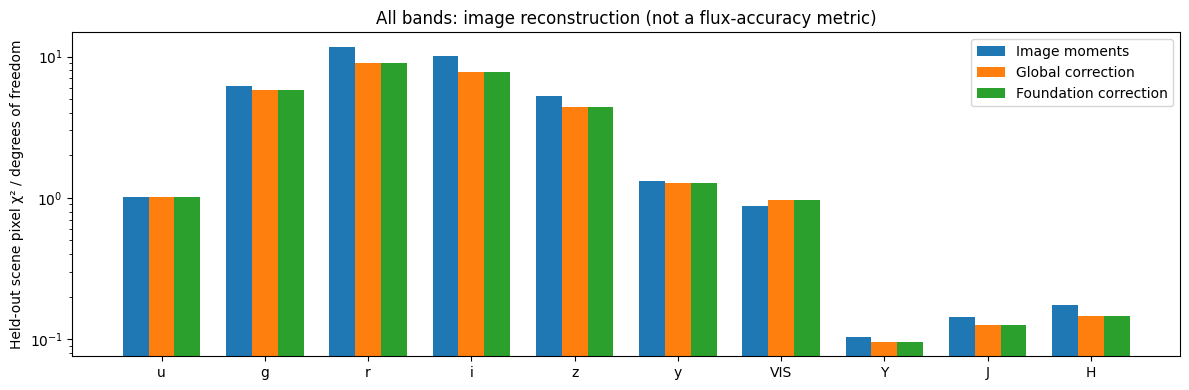

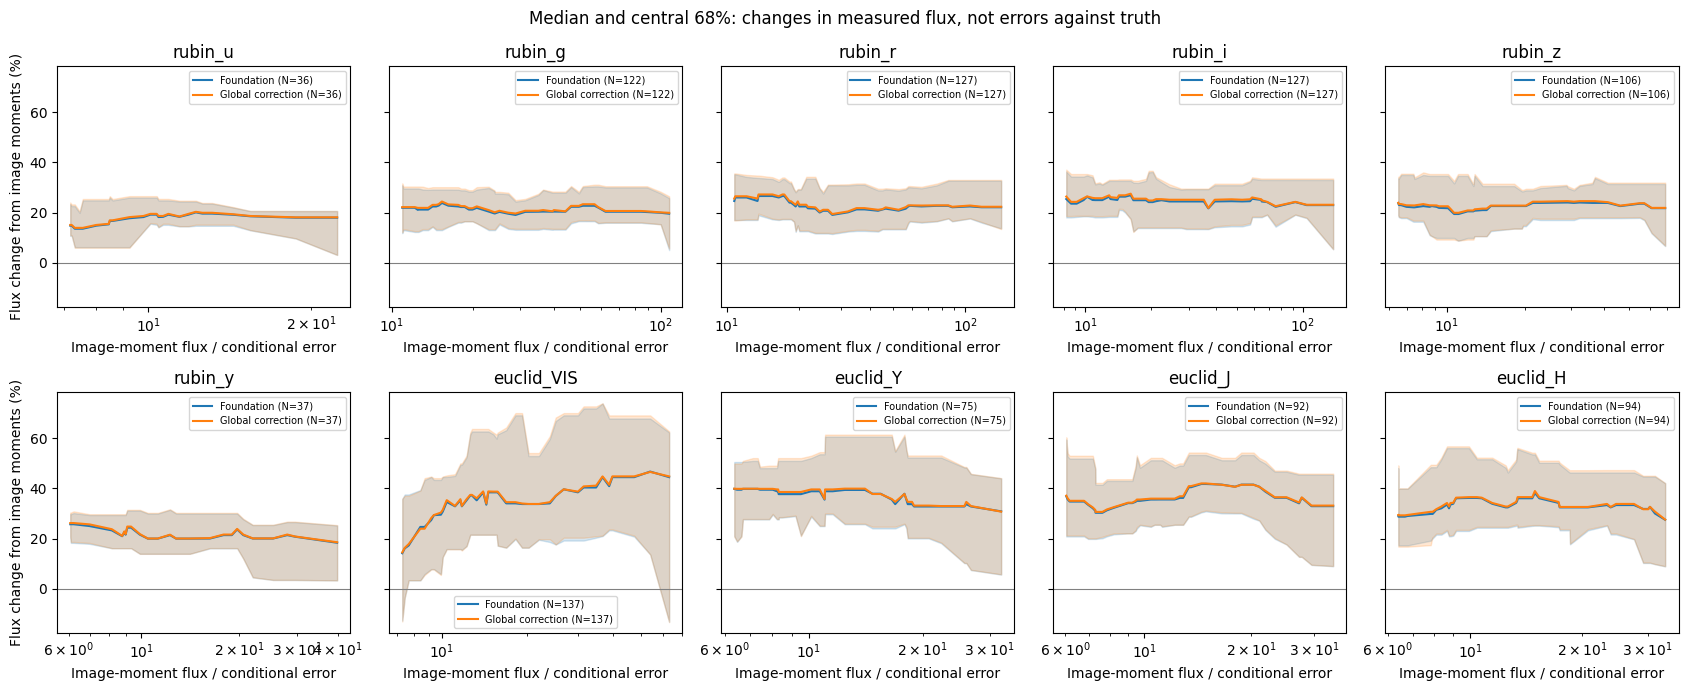

In [3]:
fit_plot, flux_plot, scene_plot = figures(RUN, CONTROL)
display(fit_plot)
display(flux_plot)
plt.close(fit_plot)
plt.close(flux_plot)

## Crowded scene on each native grid

Observed pixels and before/after residuals in units of the supplied pixel standard deviation. The displayed scene has the largest number of modeled detections in this held-out sample. All detected neighbors within the configured search region are included; undetected sources remain a limitation.

Catalog: /home/shemmati/Work/Projects/JAISP/models/photometry/self_supervised/runs/q1_all_bands/test_fluxes_flagged.csv


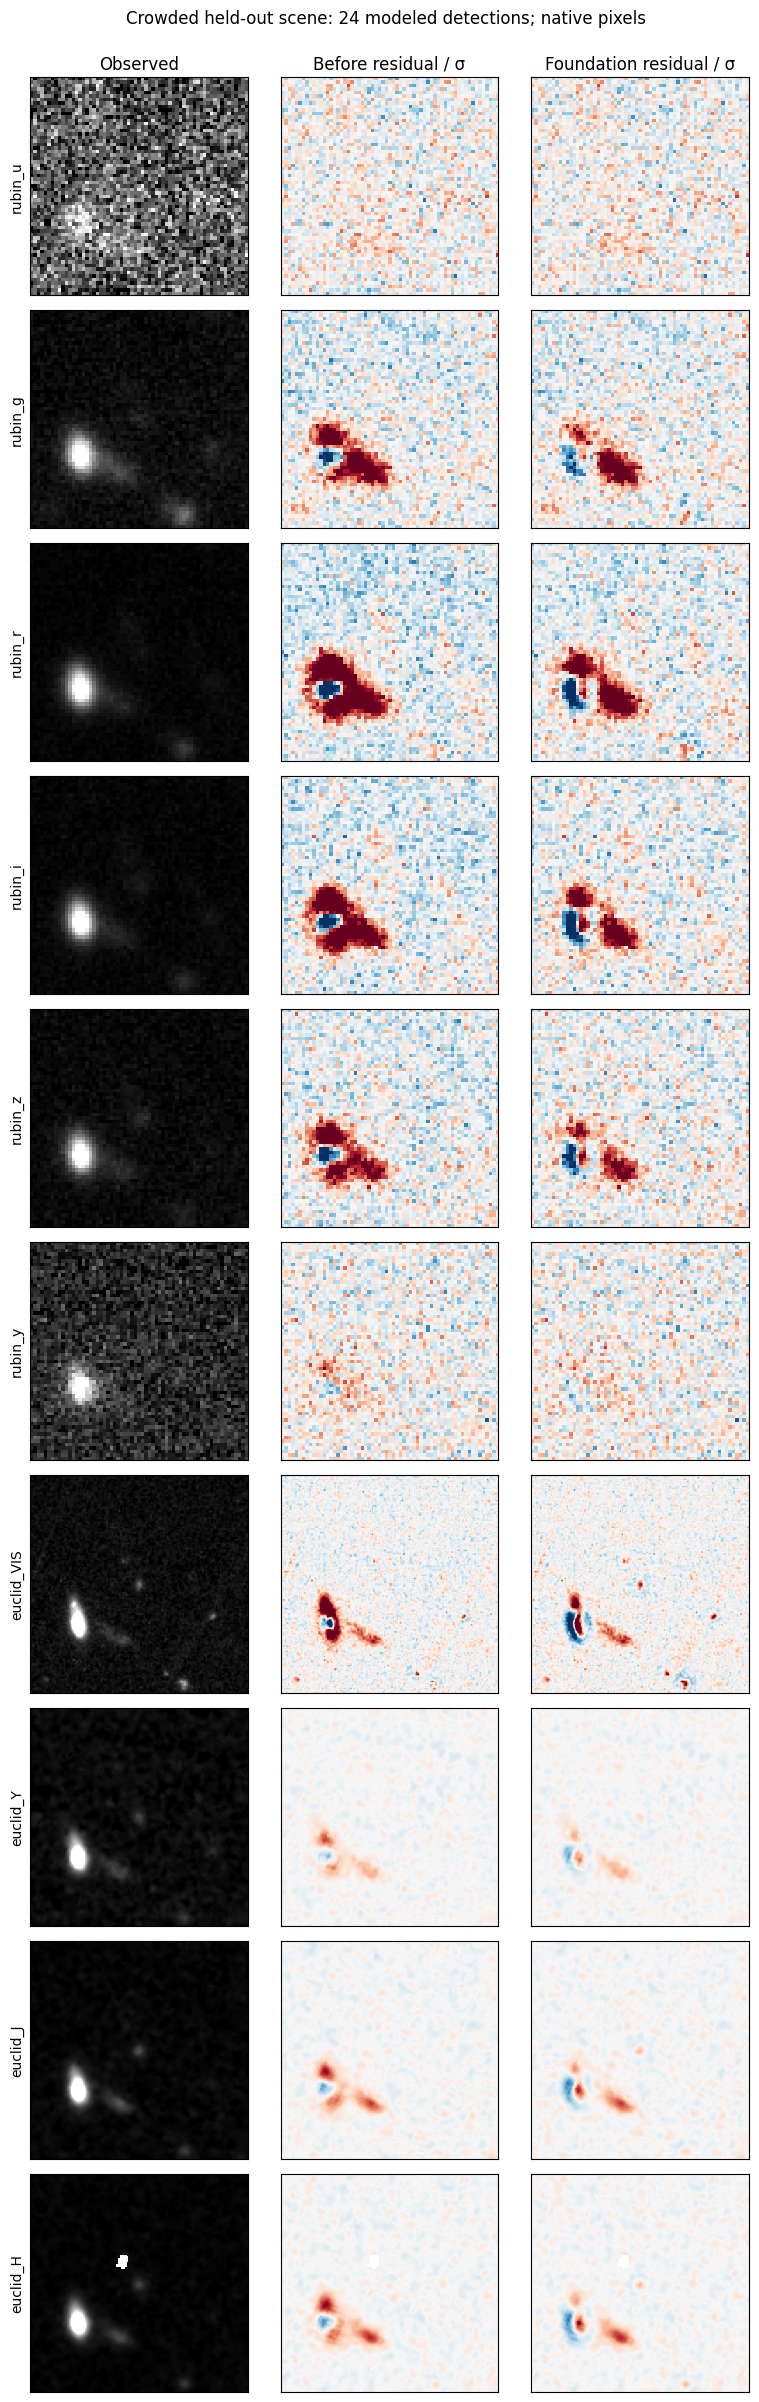

flag,OK_CONDITIONAL,PARTIAL_OR_NO_COVERAGE
band,,
rubin_u,140,408
rubin_g,140,408
rubin_r,140,408
rubin_i,141,407
rubin_z,140,408
rubin_y,140,408
euclid_VIS,142,406
euclid_Y,141,407
euclid_J,141,407


In [4]:
display(scene_plot)
plt.close(scene_plot)
fluxes = pd.read_csv(RUN / "test_fluxes_flagged.csv")
counts = fluxes[fluxes.model == "foundation"].groupby(["band", "flag"]).size().unstack(fill_value=0).reindex(BANDS)
display(counts)
print("Catalog:", RUN / "test_fluxes_flagged.csv")

## Does the trained head actually change morphology?

Identity initialization exactly reproduces image moments. The following measures the selected checkpoint's source-dependent size corrections. The global-feature control tests whether this object dependence helps image fits.

In [5]:
head, splits, checkpoint = load_run(RUN)
ratios = []
with torch.no_grad():
    for scene in splits["test"]:
        before = scene["covariance"]
        after = head(scene["features"], before)
        # sqrt(area) scale: covariance determinant is proportional to area squared.
        ratios.extend((torch.linalg.det(after) / torch.linalg.det(before)).pow(.25).tolist())
print("Linear size ratio (16%, median, 84%):", np.percentile(ratios, [16, 50, 84]))
print("Fraction within 0.1% of identity:", np.mean(np.abs(np.array(ratios) - 1) < .001))
psf = pd.DataFrame(metadata["psf"]).T.reindex(BANDS)
display(psf[["sigma_px", "n", "median_reduced_chi2"]])

Linear size ratio (16%, median, 84%): [1.79650351 1.80134761 1.80811566]
Fraction within 0.1% of identity: 0.0


,sigma_px,n,median_reduced_chi2
rubin_u,2.653916,5,1.009354
rubin_g,2.328344,22,1.386322
rubin_r,2.178498,26,1.20156
rubin_i,2.049289,25,1.128159
rubin_z,2.133027,24,1.15151
rubin_y,2.174497,12,1.133203
euclid_VIS,0.931927,38,0.761764
euclid_Y,2.061871,17,0.160133
euclid_J,2.197129,19,0.136216
euclid_H,2.397867,19,0.169138


## Result of this pilot

Across 47 held-out scenes, the foundation correction reduces pixel χ² in nine bands, but increases VIS χ² by **9.9%** relative to image moments. The constant-feature control reproduces almost all changes: its per-band pixel χ² differs from the foundation by at most **0.23%**. The learned linear size factor is nearly constant, with a median of **1.801** (16th–84th percentiles **1.797–1.808**).

**This run does not demonstrate a useful foundation-specific photometry gain.** It mainly learns a shared expansion of the initial shapes. The weighted, truncated VIS moments are an approximate initializer; their bias and the restrictive Gaussian/shared-color model need addressing before interpreting a learned correction as a morphology prior.

Do not interpret a favorable pixel-fit comparison as confirmed flux improvement. Independent Gaussian-integral and Monte Carlo tests validate the renderer, joint solver, gradients, and conditional errors. They do not validate learned morphology on real galaxies.

For a scientific flux-accuracy claim, the next experiment needs injected sources passed through the encoder again (never reuse clean-scene cached features), plus independent multiband reference photometry with established native-image zero points. A stronger image-only shape fit, flexible color-dependent shapes, spatial ePSFs, per-band position corrections, and correlated-noise treatment remain necessary before production use. Treat the present holdout as exploratory when designing the next experiment.

Reproduce preparation/training and the control with the commands in `README.md`; all ten bands are mandatory, and missing calibrators/data cause a failure rather than silently dropping a band.